In [3]:
!git clone -b rogelio_resnet50_modeling  https://github.com/seanmcgowanx/coral-reef-classification.git

Cloning into 'coral-reef-classification'...
remote: Enumerating objects: 327, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (161/161), done.
remote: Total 327 (delta 112), reused 31 (delta 31), pack-reused 135 (from 1)
Receiving objects: 100% (327/327), 77.72 MiB | 13.84 MiB/s, done.
Resolving deltas: 100% (143/143), done.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install -q -r /content/coral-reef-classification/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 129.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.8 MB/s eta 0:00:00


# ResNet-50

In [6]:
import sys
import os

def in_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

if in_colab():
    # Running in Google Colab
    repo_path = "/content/coral-reef-classification"
    data_path = "/content/coral-reef-classification/data/processed"

    # Set working directory to the repo root
    os.chdir(repo_path)

else:
    # Running locally in VS Code
    repo_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    data_path = os.path.abspath(os.path.join(repo_path, "data", "processed"))

    # Add repo root to Python path
    if repo_path not in sys.path:
        sys.path.append(repo_path)

    # Set working directory to the repo root
    os.chdir(repo_path)

print("Using repo path:", repo_path)
print("Using data path:", data_path)
print("CWD:", os.getcwd())

Using repo path: /content/coral-reef-classification
Using data path: /content/coral-reef-classification/data/processed
CWD: /content/coral-reef-classification


In [7]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

### Data Augmentations

In [76]:
# ImageNet normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_transform = T.Compose([
    # Geometric transforms
    T.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),

    # Photometric transforms
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Mild blur (simulates turbidity & motion)
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),

    # Convert & Normalize
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Define test/validation transformations
test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

### Build the CoralReefDataset Class

In [77]:
import boto3
from botocore.config import Config
from botocore import UNSIGNED
import io
from PIL import Image

# Anonymous S3 client for MERMAID public bucket
s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED)
)

def get_image_s3(image_id: str, thumbnail: bool = False,
                 bucket: str = "coral-reef-training"):
    """
    Streams a MERMAID image directly from the public S3 bucket.

    Returns a PIL.Image in RGB mode.
    """
    key = f"mermaid/{image_id}_thumbnail.png" if thumbnail else f"mermaid/{image_id}.png"

    try:
        resp = s3.get_object(Bucket=bucket, Key=key)
        img = Image.open(io.BytesIO(resp["Body"].read())).convert("RGB")
        return img
    except Exception as e:
        raise RuntimeError(f"Could not load image {image_id} from S3. Key tried: {key}. Error: {e}")

In [78]:
class CoralReefDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        # The first column must be image_id
        self.image_ids = self.df["image_id"].tolist()

        # All columns after image_id are labels
        self.label_cols = self.df.columns[1:].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]

        # Load from Mermaid public S3 bucket
        image = get_image_s3(image_id)

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(
            self.df.loc[idx, self.label_cols].values.astype("float32")
        )

        return image, labels


### Create Train, Validation, Test Datasets

In [79]:
train_csv = os.path.join(data_path, "final_labels_train.csv")
test_csv = os.path.join(data_path, "final_labels_test.csv")

# Load CSVs
df_train_full = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

# Drop metadata columns if present
meta_cols = ["region_name"]
df_train_full = df_train_full.drop(columns=[c for c in meta_cols if c in df_train_full.columns])
df_test = df_test.drop(columns=[c for c in meta_cols if c in df_test.columns])

# Label columns (starts at column 1 because col 0 is image_id)
class_names = df_train_full.columns[1:]
num_classes = len(class_names)

# Extract label matrix for stratified split
y = df_train_full[class_names].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.05,
    random_state=42
)

for train_idx, val_idx in msss.split(df_train_full, y):
    train_df = df_train_full.iloc[train_idx].reset_index(drop=True)
    val_df = df_train_full.iloc[val_idx].reset_index(drop=True)

train_dataset = CoralReefDataset(train_df, transform=train_transform)
val_dataset = CoralReefDataset(val_df, transform=test_transform)
test_dataset = CoralReefDataset(df_test, transform=test_transform)

### Create DataLoaders

In [80]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

### Build and configure the ResNet-50 model



In [81]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ImageNet-pretrained weights
weights = ResNet50_Weights.IMAGENET1K_V1
model = resnet50(weights=weights)

# Replace the fc head with dropout and linear to improve generalization
num_features = model.fc.in_features
num_classes = len(class_names)
model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(num_features, num_classes)
)

# Move model to device
model = model.to(device)

print("\nModel successfully built:")
print(model)
print(f"\nNumber of trainable parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda

Model successfully built:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): C

### Loss Function and Optimizer

In [82]:
# Loss function for multi-label classification
criterion = nn.BCEWithLogitsLoss()

# Freeze everything except the head
for name, param in model.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False

# Stage 1 optimizer (head only, backbone frozen initially)
optimizer_stage1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-5
)

# Learning rate scheduler for Stage 1
scheduler_stage1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage1,
    T_max=5
)

### Stage 1 Training



In [87]:
def validate(model, loader, criterion, device):
    # Runs one validation epoch

    model.eval()

    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            n_batches += 1

    # Compute mean over all batches
    val_loss = total_loss / n_batches

    return val_loss

In [88]:
def train_stage_1(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    num_epochs=5,
    ckpt_path="resnet50_stage1_best.pth"
):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = 0.0

    print("\n===== Starting Stage 1 Training =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        n_batches    = 0

        # Train loop
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()

            # Stability for small head
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()

            running_loss += loss.item()
            n_batches    += 1

        train_loss = running_loss / n_batches

        val_loss = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"Train Loss: {train_loss:.4f} | Val   Loss: {val_loss:.4f}\n"
        )

        # Save best model based on val f1 score
        if val_loss < best_val_loss:
            best_val_f1 = val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                },
                ckpt_path
            )
            print(f"Saved best Stage 1 model (Val loss: {best_val_loss:.4f})")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    return history

### Run Stage 1 Training

In [86]:
history_stage1 = train_stage_1(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_stage1,
    scheduler=scheduler_stage1,
    device=device,
    num_epochs=5,
    threshold=0.5,
    ckpt_path="resnet50_stage1_best.pth"
)


===== Starting Stage 1 Training =====



KeyboardInterrupt: 

In [36]:
save_path = "/content/drive/MyDrive/resnet50_model/stage_training/"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), save_path + "resnet50_stage1_best.pth")

print("Saved model to:", save_path)

Saved model to: /content/drive/MyDrive/resnet50_model/stage_training/


### Plot Stage 1 Learning Curves

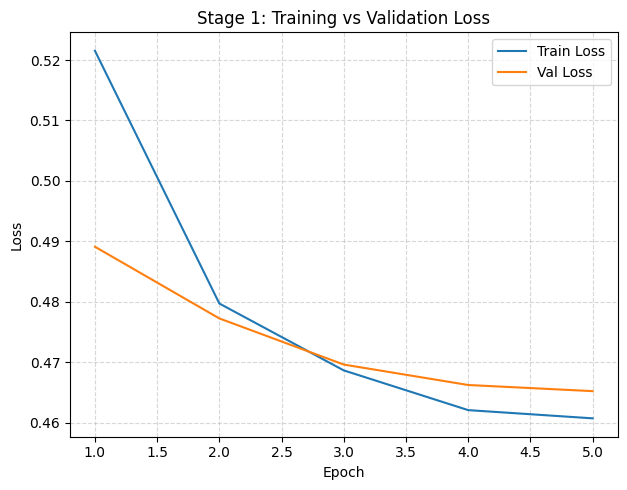

In [37]:
epochs = range(1, len(history_stage1["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage1["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage1["val_loss"], label="Val Loss")
plt.title("Stage 1: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Stage 2 Training

In [47]:
def unfreeze_stage2(model, freeze_until="layer2"):
    # Unfreezes layers deeper than 'freeze_until'

    freeze_map = {
        "conv1": [],
        "layer1": ["layer1", "layer2", "layer3", "layer4"],
        "layer2": ["layer2", "layer3", "layer4"],
        "layer3": ["layer3", "layer4"],
        "layer4": ["layer4"],
    }

    to_unfreeze = freeze_map.get(freeze_until, ["layer3", "layer4"])

    # Freeze everything by default
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze desired deeper layers
    for name, module in model.named_children():
        if name in to_unfreeze:
            for param in module.parameters():
                param.requires_grad = True

    # Ensure classifier is unfrozen
    for param in model.fc.parameters():
        param.requires_grad = True

    print(f"\nStage 2 unfreezing complete. Layers unfrozen: {to_unfreeze}")

In [51]:
def train_stage_2(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    patience=3,
    num_epochs=10,
    ckpt_path="resnet50_stage2_best.pth"
):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val_loss = 0.0
    best_state = None
    patience_counter = 0

    print("\n===== Starting Stage 2 Fine-Tuning =====\n")

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()

            # stability improvement
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

            optimizer.step()

            running_loss += loss.item()
            n_batches += 1

        train_loss = running_loss / n_batches

        val_loss = validate(model, val_loader, criterion, device)

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch [{epoch}/{num_epochs}]\n"
            f"Train Loss: {train_loss:.4f} | Val   Loss: {val_loss:.4f}\n"
        )

        # Early stopping and save best model based on F1
        if val_loss < best_val_loss:
            best_val_f1 = val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict()
                },
                ckpt_path
            )
            best_state = model.state_dict()
            patience_counter = 0
            print(f"New best Stage 2 model saved! Val Loss = {best_val_loss:.4f}\n")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

    # Restore best model
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

### Update model

In [ ]:
old_fc = model.fc[1]
model.fc = nn.Sequential(
    nn.Dropout(0.3), # increased to reduce overfitting
    old_fc
)

model.to(device)

### Set Stage 2 optimizer

In [73]:
# Lower LR for fine-tuning
optimizer_stage2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-5
)

scheduler_stage2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_stage2,
    T_max=10
)

### Unfreeze remaining layers and Run Stage 2 Traninig

In [75]:
# Unfreeze deeper layers
unfreeze_stage2(model, freeze_until="layer2")

# Start Stage 2 fine-tuning
history_stage2 = train_stage_2(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_stage2,
    scheduler=scheduler_stage2,
    device=device,
    num_epochs=10,
    patience=2,
    ckpt_path="resnet50_stage2_best.pth"
)


Stage 2 unfreezing complete. Layers unfrozen: ['layer2', 'layer3', 'layer4']

===== Starting Stage 2 Fine-Tuning =====



KeyboardInterrupt: 

In [ ]:
save_path = "/content/drive/MyDrive/resnet50_model/stage_training/"
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(model.state_dict(), save_path + "resnet50_stage2_best.pth")

print("Saved model to:", save_path)

### Plot Stage 2 Learning Curve

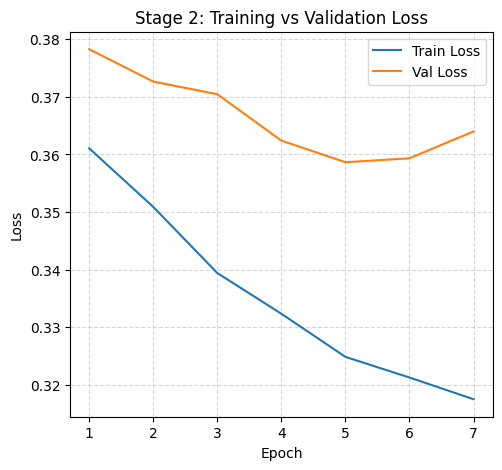

In [59]:
epochs = range(1, len(history_stage2["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs, history_stage2["train_loss"], label="Train Loss")
plt.plot(epochs, history_stage2["val_loss"], label="Val Loss")
plt.title("Stage 2: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()